### M1244017 M1244022 Text Mining Final Project<p>
Dataset: https://www.kaggle.com/datasets/mohamedbakhet/amazon-books-reviews/data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import Packages

In [2]:
import spacy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords,wordnet
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
import gensim
from gensim import corpora
from gensim.models.ldamodel import LdaModel
from gensim.models import CoherenceModel

In [3]:
!pip install wordcloud
import wordcloud

In [4]:
import wordcloud
from wordcloud import WordCloud

In [5]:
!pip install pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 41.0 MB/s eta 0:00:00


In [6]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

### Import Combined Dataset

In [ ]:
df_Combined = pd.read_csv('/Users/kao900531/Desktop/TextMining_FinalProject/combined_dataset.csv')

In [ ]:
df_Combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 19 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Title               object 
 1   description         object 
 2   authors             object 
 3   image               object 
 4   previewLink         object 
 5   publisher           object 
 6   publishedDate       object 
 7   infoLink            object 
 8   categories          object 
 9   ratingsCount        float64
 10  Id                  object 
 11  Price               float64
 12  User_id             object 
 13  profileName         object 
 14  review/helpfulness  object 
 15  review/score        float64
 16  review/time         int64  
 17  review/summary      object 
 18  review/text         object 
dtypes: float64(3), int64(1), object(15)
memory usage: 434.9+ MB


### Import Processed Dataset

In [7]:
df_Processed = pd.read_csv('/content/drive/MyDrive/Text Mining/Final Project/Source Data/processed_dataset.csv')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
df_Processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111011 entries, 0 to 2111010
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Title           object 
 1   authors         object 
 2   publishedDate   object 
 3   categories      object 
 4   review/score    float64
 5   review/summary  object 
 6   review/text     object 
dtypes: float64(1), object(6)
memory usage: 112.7+ MB


In [ ]:
df_Processed.head(5)

,Title,authors,publishedDate,categories,review/score,review/summary,review/text
0,Its Only Art If Its Well Hung!,Julie Strain,1996,Comics & Graphic Novels,4.0,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...
1,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,5.0,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
2,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,5.0,Essential for every personal and Public Library,"If people become the books they read and if ""t..."
3,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,4.0,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,4.0,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...


### Import corpus1

In [8]:
df_corpus1 = pd.read_csv('/content/drive/MyDrive/Text Mining/Final Project/Source Data/corpus1.csv')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
df_corpus1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15753 entries, 0 to 15752
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              15753 non-null  object 
 1   authors            15753 non-null  object 
 2   publishedDate      15753 non-null  int64  
 3   categories         15753 non-null  object 
 4   review/score       15753 non-null  float64
 5   review/summary     15753 non-null  object 
 6   review/text        15753 non-null  object 
 7   review_word_count  15753 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 984.7+ KB


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
df_corpus1.head(5)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Title,authors,publishedDate,categories,review/score,review/summary,review/text,review_word_count
0,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,5.0,Teachers buy this over iTunes or Audible versi...,I bought the audio CD's about 5 years ago from...,261
1,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,5.0,"A map, the book, and GOLD PAGES :O","Any fan, or non fan will love this. First of a...",124
2,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,5.0,A classic that only gets better with age,A true good versus evil story and what is best...,129
3,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,3.0,The Hobbit in Review,The Hobbit is a book about and hobbit named Bi...,146
4,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,3.0,My Hobbit Review,This is a story about a Hobbit whose name is B...,443


### Import Corpus 2

In [ ]:
df_corpus2 = pd.read_csv('/content/drive/MyDrive/Text Mining/Final Project/Source Data/corpus2.csv')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
df_corpus2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86598 entries, 0 to 86597
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              86598 non-null  object 
 1   authors            86598 non-null  object 
 2   publishedDate      86598 non-null  int64  
 3   categories         86598 non-null  object 
 4   review/score       86598 non-null  float64
 5   review/summary     86598 non-null  object 
 6   review/text        86598 non-null  object 
 7   review_word_count  86598 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 5.3+ MB


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
df_corpus2.head(5)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Title,authors,publishedDate,categories,review/score,review/summary,review/text,review_word_count
0,Seance,Kevin Valgaeren,2016,Fiction,5.0,Tales of the world I never knew and never will,"Thanks to my grandparents, who came to America...",324
1,Seance,Kevin Valgaeren,2016,Fiction,5.0,Excellent - as good as it gets!,Isaac Bashevis Singer was no doubt one of the ...,136
2,Seance,Kevin Valgaeren,2016,Fiction,4.0,Short stories that use Jewish peasant life to ...,THE S&Eacute;ANCE AND OTHER STORIES is a colle...,227
3,Night World: Daughters Of Darkness,L.J. Smith,2016,Juvenile Fiction,5.0,one of the best night world books!!!!,first of all i thought that this was one of lj...,211
4,Night World: Daughters Of Darkness,L.J. Smith,2016,Juvenile Fiction,5.0,The Best of the Night World,Though the plot is much like that of Pride and...,210


# Data Preprocessing

## Load the dataset

In [9]:
BookData = '/content/drive/MyDrive/Text Mining/Final Project/Source Data/books_data.csv'
#BookRating = '/content/drive/MyDrive/Text Mining/Final Project/Source Data/Books_rating.csv'
df_Data = pd.read_csv(BookData)
#df_Rating = pd.read_csv(BookRating)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
df_Data.head(10)

,Title,description,authors,image,previewLink,publisher,publishedDate,infoLink,categories,ratingsCount
0,Its Only Art If Its Well Hung!,NaN,['Julie Strain'],http://books.google.com/books/content?id=DykPA...,http://books.google.nl/books?id=DykPAAAACAAJ&d...,NaN,1996,http://books.google.nl/books?id=DykPAAAACAAJ&d...,['Comics & Graphic Novels'],NaN
1,Dr. Seuss: American Icon,Philip Nel takes a fascinating look into the k...,['Philip Nel'],http://books.google.com/books/content?id=IjvHQ...,http://books.google.nl/books?id=IjvHQsCn_pgC&p...,A&C Black,2005-01-01,http://books.google.nl/books?id=IjvHQsCn_pgC&d...,['Biography & Autobiography'],NaN
2,Wonderful Worship in Smaller Churches,This resource includes twelve principles in un...,['David R. Ray'],http://books.google.com/books/content?id=2tsDA...,http://books.google.nl/books?id=2tsDAAAACAAJ&d...,NaN,2000,http://books.google.nl/books?id=2tsDAAAACAAJ&d...,['Religion'],NaN
3,Whispers of the Wicked Saints,Julia Thomas finds her life spinning out of co...,['Veronica Haddon'],http://books.google.com/books/content?id=aRSIg...,http://books.google.nl/books?id=aRSIgJlq6JwC&d...,iUniverse,2005-02,http://books.google.nl/books?id=aRSIgJlq6JwC&d...,['Fiction'],NaN
4,"Nation Dance: Religion, Identity and Cultural ...",NaN,['Edward Long'],NaN,http://books.google.nl/books?id=399SPgAACAAJ&d...,NaN,2003-03-01,http://books.google.nl/books?id=399SPgAACAAJ&d...,NaN,NaN
5,The Church of Christ: A Biblical Ecclesiology ...,In The Church of Christ: A Biblical Ecclesiolo...,['Everett Ferguson'],http://books.google.com/books/content?id=kVqRa...,http://books.google.nl/books?id=kVqRaiPlx88C&p...,Wm. B. Eerdmans Publishing,1996,http://books.google.nl/books?id=kVqRaiPlx88C&d...,['Religion'],5.0
6,The Overbury affair (Avon),NaN,['Miriam Allen De Ford'],NaN,http://books.google.nl/books?id=mHLTngEACAAJ&d...,NaN,1960,http://books.google.nl/books?id=mHLTngEACAAJ&d...,NaN,NaN
7,A Walk in the Woods: a Play in Two Acts,NaN,['Lee Blessing'],NaN,http://books.google.nl/books?id=6HDOwAEACAAJ&d...,NaN,1988,http://books.google.nl/books?id=6HDOwAEACAAJ&d...,NaN,3.0
8,Saint Hyacinth of Poland,The story for children 10 and up of St. Hyacin...,['Mary Fabyan Windeatt'],http://books.google.com/books/content?id=lmLqA...,http://books.google.nl/books?id=lmLqAAAACAAJ&d...,Tan Books & Pub,2009-01-01,http://books.google.nl/books?id=lmLqAAAACAAJ&d...,['Biography & Autobiography'],NaN
9,Rising Sons and Daughters: Life Among Japan's ...,Wardell recalls his experience as a foreign st...,['Steven Wardell'],NaN,http://books.google.nl/books?id=rbLZugEACAAJ&d...,Plympton PressIntl,1995,http://books.google.nl/books?id=rbLZugEACAAJ&d...,['Social Science'],NaN


In [ ]:
df_Rating.head(10)

,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,1882931173,Its Only Art If Its Well Hung!,NaN,AVCGYZL8FQQTD,"Jim of Oz ""jim-of-oz""",7/7,4.0,940636800,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...
1,0826414346,Dr. Seuss: American Icon,NaN,A30TK6U7DNS82R,Kevin Killian,10/10,5.0,1095724800,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
2,0826414346,Dr. Seuss: American Icon,NaN,A3UH4UZ4RSVO82,John Granger,10/11,5.0,1078790400,Essential for every personal and Public Library,"If people become the books they read and if ""t..."
3,0826414346,Dr. Seuss: American Icon,NaN,A2MVUWT453QH61,"Roy E. Perry ""amateur philosopher""",7/7,4.0,1090713600,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,0826414346,Dr. Seuss: American Icon,NaN,A22X4XUPKF66MR,"D. H. Richards ""ninthwavestore""",3/3,4.0,1107993600,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...
5,0826414346,Dr. Seuss: American Icon,NaN,A2F6NONFUDB6UK,Malvin,2/2,4.0,1127174400,One of America's greatest creative talents,"""Dr. Seuss: American Icon"" by Philip Nel is a ..."
6,0826414346,Dr. Seuss: American Icon,NaN,A14OJS0VWMOSWO,Midwest Book Review,3/4,5.0,1100131200,A memorably excellent survey of Dr. Seuss' man...,Theodor Seuss Giesel was best known as 'Dr. Se...
7,0826414346,Dr. Seuss: American Icon,NaN,A2RSSXTDZDUSH4,J. Squire,0/0,5.0,1231200000,Academia At It's Best,When I recieved this book as a gift for Christ...
8,0826414346,Dr. Seuss: American Icon,NaN,A25MD5I2GUIW6W,"J. P. HIGBED ""big fellow""",0/0,5.0,1209859200,And to think that I read it on the tram!,Trams (or any public transport) are not usuall...
9,0826414346,Dr. Seuss: American Icon,NaN,A3VA4XFS5WNJO3,Donald Burnside,3/5,4.0,1076371200,Fascinating account of a genius at work,"As far as I am aware, this is the first book-l..."


## Show the Statistical Data of Each Files

In [ ]:
df_Data.describe()

,ratingsCount
count,49752.000000
mean,21.252975
std,201.340431
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,4895.000000


In [ ]:
df_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212404 entries, 0 to 212403
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Title          212403 non-null  object 
 1   description    143962 non-null  object 
 2   authors        180991 non-null  object 
 3   image          160329 non-null  object 
 4   previewLink    188568 non-null  object 
 5   publisher      136518 non-null  object 
 6   publishedDate  187099 non-null  object 
 7   infoLink       188568 non-null  object 
 8   categories     171205 non-null  object 
 9   ratingsCount   49752 non-null   float64
dtypes: float64(1), object(9)
memory usage: 16.2+ MB


In [ ]:
df_Rating.describe()

,Price,review/score,review/time
count,481171.000000,3.000000e+06,3.000000e+06
mean,21.762656,4.215289e+00,1.132307e+09
std,26.206541,1.203054e+00,1.493202e+08
min,1.000000,1.000000e+00,-1.000000e+00
25%,10.780000,4.000000e+00,9.999072e+08
50%,14.930000,5.000000e+00,1.128298e+09
75%,23.950000,5.000000e+00,1.269130e+09
max,995.000000,5.000000e+00,1.362355e+09


In [ ]:
df_Rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 10 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Id                  object 
 1   Title               object 
 2   Price               float64
 3   User_id             object 
 4   profileName         object 
 5   review/helpfulness  object 
 6   review/score        float64
 7   review/time         int64  
 8   review/summary      object 
 9   review/text         object 
dtypes: float64(2), int64(1), object(7)
memory usage: 228.9+ MB


## Use 'Title' to Combine Two csv files & Remove Unessential Attributes

In [ ]:
df_Combined = pd.merge(df_Data, df_Rating, on='Title')
df_Combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 19 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Title               object 
 1   description         object 
 2   authors             object 
 3   image               object 
 4   previewLink         object 
 5   publisher           object 
 6   publishedDate       object 
 7   infoLink            object 
 8   categories          object 
 9   ratingsCount        float64
 10  Id                  object 
 11  Price               float64
 12  User_id             object 
 13  profileName         object 
 14  review/helpfulness  object 
 15  review/score        float64
 16  review/time         int64  
 17  review/summary      object 
 18  review/text         object 
dtypes: float64(3), int64(1), object(15)
memory usage: 434.9+ MB


### Export Combined Dataset

In [ ]:
df_Combined.to_csv('combined_dataset.csv', index=False)

### We only keep 'Title', 'authors', 'publishedDate', 'categories', 'review/score', 'review/summary', 'review/text'.

In [ ]:
df_CombinedSelected = df_Combined[['Title', 'authors', 'publishedDate', 'categories', 'review/score', 'review/summary', 'review/text']]
df_CombinedSelected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Title           object 
 1   authors         object 
 2   publishedDate   object 
 3   categories      object 
 4   review/score    float64
 5   review/summary  object 
 6   review/text     object 
dtypes: float64(1), object(6)
memory usage: 160.2+ MB


In [ ]:
df_CombinedSelected.head(10)

,Title,authors,publishedDate,categories,review/score,review/summary,review/text
0,Its Only Art If Its Well Hung!,['Julie Strain'],1996,['Comics & Graphic Novels'],4.0,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...
1,Dr. Seuss: American Icon,['Philip Nel'],2005-01-01,['Biography & Autobiography'],5.0,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
2,Dr. Seuss: American Icon,['Philip Nel'],2005-01-01,['Biography & Autobiography'],5.0,Essential for every personal and Public Library,"If people become the books they read and if ""t..."
3,Dr. Seuss: American Icon,['Philip Nel'],2005-01-01,['Biography & Autobiography'],4.0,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,Dr. Seuss: American Icon,['Philip Nel'],2005-01-01,['Biography & Autobiography'],4.0,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...
5,Dr. Seuss: American Icon,['Philip Nel'],2005-01-01,['Biography & Autobiography'],4.0,One of America's greatest creative talents,"""Dr. Seuss: American Icon"" by Philip Nel is a ..."
6,Dr. Seuss: American Icon,['Philip Nel'],2005-01-01,['Biography & Autobiography'],5.0,A memorably excellent survey of Dr. Seuss' man...,Theodor Seuss Giesel was best known as 'Dr. Se...
7,Dr. Seuss: American Icon,['Philip Nel'],2005-01-01,['Biography & Autobiography'],5.0,Academia At It's Best,When I recieved this book as a gift for Christ...
8,Dr. Seuss: American Icon,['Philip Nel'],2005-01-01,['Biography & Autobiography'],5.0,And to think that I read it on the tram!,Trams (or any public transport) are not usuall...
9,Dr. Seuss: American Icon,['Philip Nel'],2005-01-01,['Biography & Autobiography'],4.0,Fascinating account of a genius at work,"As far as I am aware, this is the first book-l..."


## Remove brackets and colons from 'authors', 'categories' Attributes.

In [ ]:
df_CombinedSelected['authors'] = df_CombinedSelected['authors'].str.extract(r'\'(.*)\'')
df_CombinedSelected['categories'] = df_CombinedSelected['categories'].str.extract(r'\'(.*)\'')
df_CombinedSelected.head(10)

/var/folders/pp/zbsg_ng90wb4m9xygzzdq67m0000gn/T/ipykernel_86673/1556854664.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CombinedSelected['authors'] = df_CombinedSelected['authors'].str.extract(r'\'(.*)\'')
/var/folders/pp/zbsg_ng90wb4m9xygzzdq67m0000gn/T/ipykernel_86673/1556854664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CombinedSelected['categories'] = df_CombinedSelected['categories'].str.extract(r'\'(.*)\'')


,Title,authors,publishedDate,categories,review/score,review/summary,review/text
0,Its Only Art If Its Well Hung!,Julie Strain,1996,Comics & Graphic Novels,4.0,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...
1,Dr. Seuss: American Icon,Philip Nel,2005-01-01,Biography & Autobiography,5.0,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
2,Dr. Seuss: American Icon,Philip Nel,2005-01-01,Biography & Autobiography,5.0,Essential for every personal and Public Library,"If people become the books they read and if ""t..."
3,Dr. Seuss: American Icon,Philip Nel,2005-01-01,Biography & Autobiography,4.0,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,Dr. Seuss: American Icon,Philip Nel,2005-01-01,Biography & Autobiography,4.0,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...
5,Dr. Seuss: American Icon,Philip Nel,2005-01-01,Biography & Autobiography,4.0,One of America's greatest creative talents,"""Dr. Seuss: American Icon"" by Philip Nel is a ..."
6,Dr. Seuss: American Icon,Philip Nel,2005-01-01,Biography & Autobiography,5.0,A memorably excellent survey of Dr. Seuss' man...,Theodor Seuss Giesel was best known as 'Dr. Se...
7,Dr. Seuss: American Icon,Philip Nel,2005-01-01,Biography & Autobiography,5.0,Academia At It's Best,When I recieved this book as a gift for Christ...
8,Dr. Seuss: American Icon,Philip Nel,2005-01-01,Biography & Autobiography,5.0,And to think that I read it on the tram!,Trams (or any public transport) are not usuall...
9,Dr. Seuss: American Icon,Philip Nel,2005-01-01,Biography & Autobiography,4.0,Fascinating account of a genius at work,"As far as I am aware, this is the first book-l..."


### Regularize the 'publishedDate' By Keeping Year Only

In [ ]:
df_CombinedSelected['publishedDate'] = df_CombinedSelected['publishedDate'].apply(lambda x: str(x)[:4])
df_CombinedSelected.head(10)


/var/folders/pp/zbsg_ng90wb4m9xygzzdq67m0000gn/T/ipykernel_86673/2104266113.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CombinedSelected['publishedDate'] = df_CombinedSelected['publishedDate'].apply(lambda x: str(x)[:4])


,Title,authors,publishedDate,categories,review/score,review/summary,review/text
0,Its Only Art If Its Well Hung!,Julie Strain,1996,Comics & Graphic Novels,4.0,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...
1,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,5.0,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
2,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,5.0,Essential for every personal and Public Library,"If people become the books they read and if ""t..."
3,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,4.0,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,4.0,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...
5,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,4.0,One of America's greatest creative talents,"""Dr. Seuss: American Icon"" by Philip Nel is a ..."
6,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,5.0,A memorably excellent survey of Dr. Seuss' man...,Theodor Seuss Giesel was best known as 'Dr. Se...
7,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,5.0,Academia At It's Best,When I recieved this book as a gift for Christ...
8,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,5.0,And to think that I read it on the tram!,Trams (or any public transport) are not usuall...
9,Dr. Seuss: American Icon,Philip Nel,2005,Biography & Autobiography,4.0,Fascinating account of a genius at work,"As far as I am aware, this is the first book-l..."


## Remove NA/Duplicated Values in Combined Dataset

### Examine Each Attribute Whether NA/Duplicated Values Exist

In [ ]:
# Check for NA values
na_values = df_CombinedSelected.isna().sum()
print("NA Values:")
print(na_values)

# Check for duplicated values
duplicated_values = df_CombinedSelected.duplicated().sum()
print("\nDuplicated Values:")
print(duplicated_values)

NA Values:
Title                208
authors           405009
publishedDate          0
categories        561629
review/score           0
review/summary       407
review/text            8
dtype: int64

Duplicated Values:
378849


### Drop NA/Duplicated Values

In [ ]:
df_CombinedSelected = df_CombinedSelected.dropna()
df_CombinedSelected = df_CombinedSelected.drop_duplicates()

df_CombinedSelected.info()
df_CombinedSelected.shape

<class 'pandas.core.frame.DataFrame'>
Index: 2091935 entries, 0 to 2999995
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Title           object 
 1   authors         object 
 2   publishedDate   object 
 3   categories      object 
 4   review/score    float64
 5   review/summary  object 
 6   review/text     object 
dtypes: float64(1), object(6)
memory usage: 127.7+ MB


(2091935, 7)

In [ ]:
# Check for NA values
na_values = df_CombinedSelected.isnull().sum()
print("NA Values:")
print(na_values)

# Check for duplicated values
duplicated_values = df_CombinedSelected.duplicated().sum()
print("\nDuplicated Values:")
print(duplicated_values)

NA Values:
Title             0
authors           0
publishedDate     0
categories        0
review/score      0
review/summary    0
review/text       0
dtype: int64

Duplicated Values:
0


### Export the Combined Dataset as a CSV File

In [ ]:
df_Processed = df_CombinedSelected.copy()
df_CombinedSelected.to_csv('processed_dataset.csv', index=False)

# Exploration Data Analysis (EDA)

In [ ]:
print(df_Processed.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2091935 entries, 0 to 2999995
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Title           object 
 1   authors         object 
 2   publishedDate   object 
 3   categories      object 
 4   review/score    float64
 5   review/summary  object 
 6   review/text     object 
dtypes: float64(1), object(6)
memory usage: 127.7+ MB
None


## Show the Difference of Records Number Before & After Processing

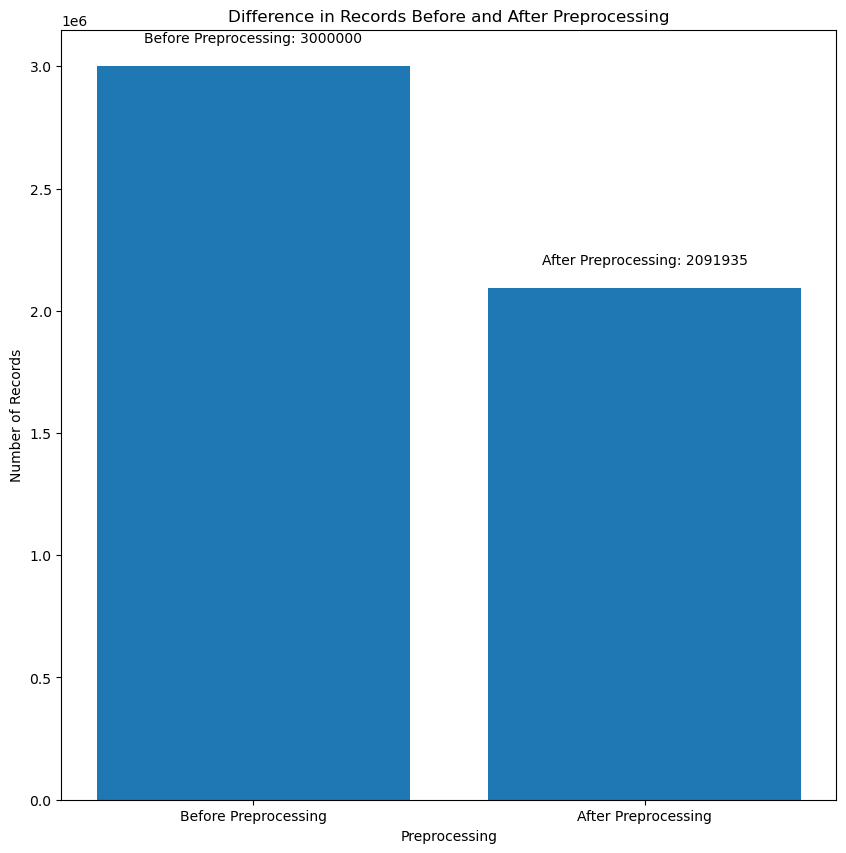

In [ ]:
import matplotlib.pyplot as plt

# Number of records before preprocessing
num_records_before = df_Combined.shape[0]

# Perform data preprocessing

# Number of records after preprocessing
num_records_after = df_Processed.shape[0]

# Create a histogram
plt.figure(figsize=(10, 10))
plt.bar(['Before Preprocessing', 'After Preprocessing'], [num_records_before, num_records_after])
plt.xlabel('Preprocessing')
plt.ylabel('Number of Records')
plt.title('Difference in Records Before and After Preprocessing')

# Add the number of records on top of the figure
plt.text(0, num_records_before + 100000, f'Before Preprocessing: {num_records_before}', ha='center')
plt.text(1, num_records_after + 100000, f'After Preprocessing: {num_records_after}', ha='center')

plt.show()

## Show the Top 10 Categories

categories
Fiction                      671030
Juvenile Fiction             165561
Biography & Autobiography     96022
Religion                      84511
History                       82273
Business & Economics          61417
Computers                     41709
Cooking                       28819
Social Science                27963
Family & Relationships        27685
Name: count, dtype: int64


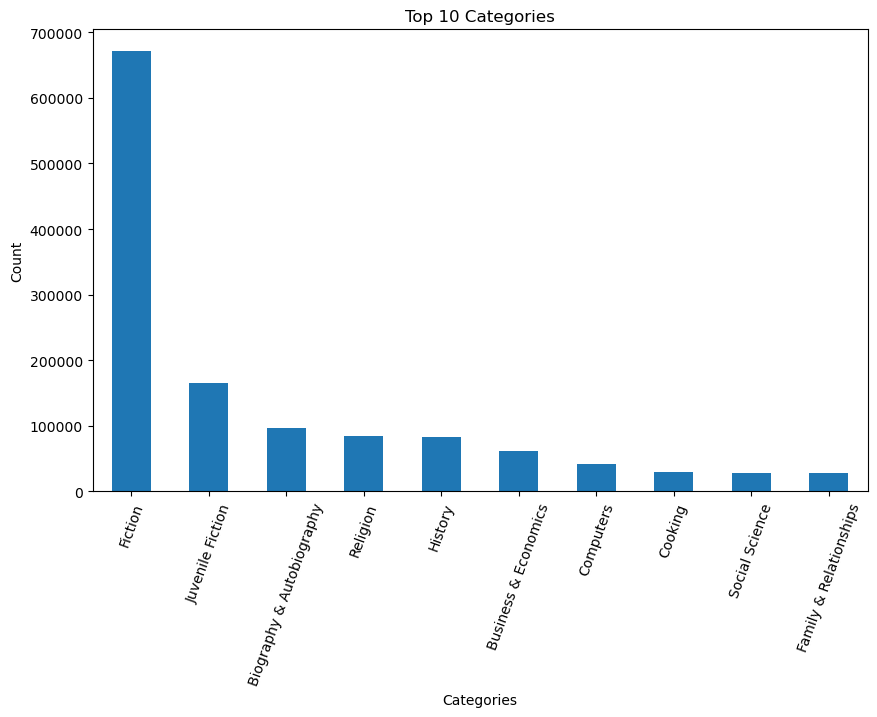

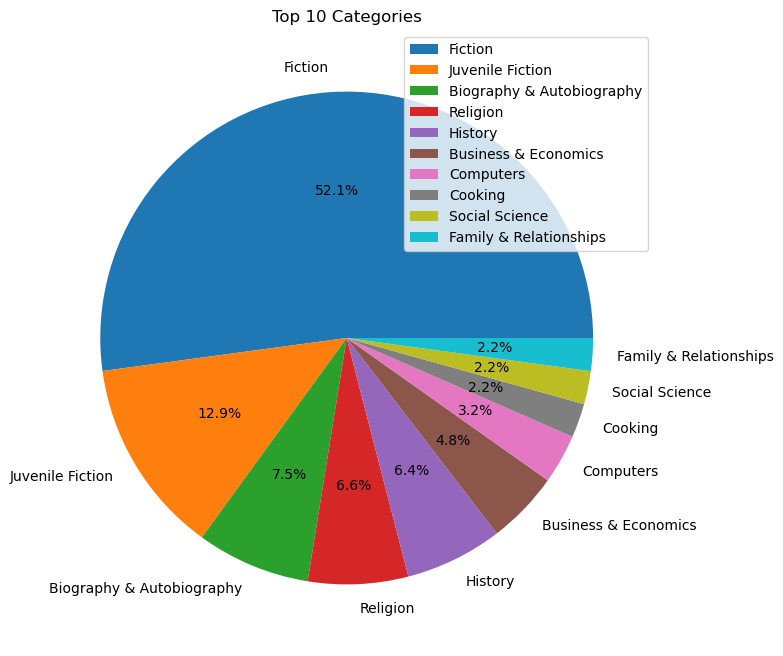

In [ ]:
import matplotlib.pyplot as plt

# Get the top 10 categories
top_10_categories = df_Processed['categories'].value_counts().head(10)
print(top_10_categories)
type(top_10_categories)

# Create a histogram
plt.figure(figsize=(10, 6))
top_10_categories.plot(kind='bar')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.title('Top 10 Categories')
plt.xticks(rotation=70)

# Create a pie chart
plt.figure(figsize=(8, 8))
df_Processed['categories'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Categories')
plt.legend()
plt.ylabel('')
plt.show()

It is obvious that the 'Fiction' category accounts the most. Thus, the following process will delve into the 'Fiction' category.

## Most Review/text Books in Fiction Category

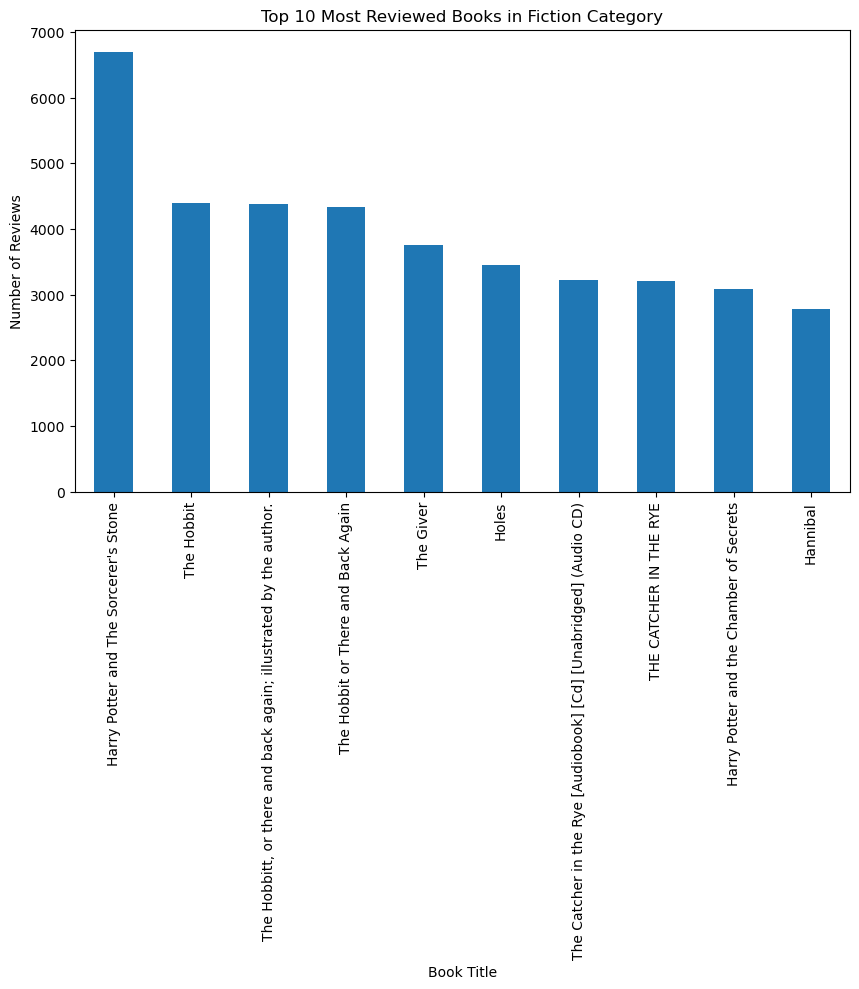

In [ ]:
# Filter the DataFrame to include only the fiction category
fiction_df = df_Processed[df_Processed['categories'].str.contains('Fiction', case=False, na=False)]

# Group by the book title and count the number of reviews for each title
book_review_counts = fiction_df.groupby('Title')['review/text'].count().sort_values(ascending=False)

# Select the top 10 most reviewed books
top_10_books = book_review_counts.head(10)

# Plot the results
plt.figure(figsize=(10, 6))
top_10_books.plot(kind='bar')
plt.title('Top 10 Most Reviewed Books in Fiction Category')
plt.xlabel('Book Title')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=90)
plt.show()

## Top 10 Authors with 5 star Ratings in Fiction Category

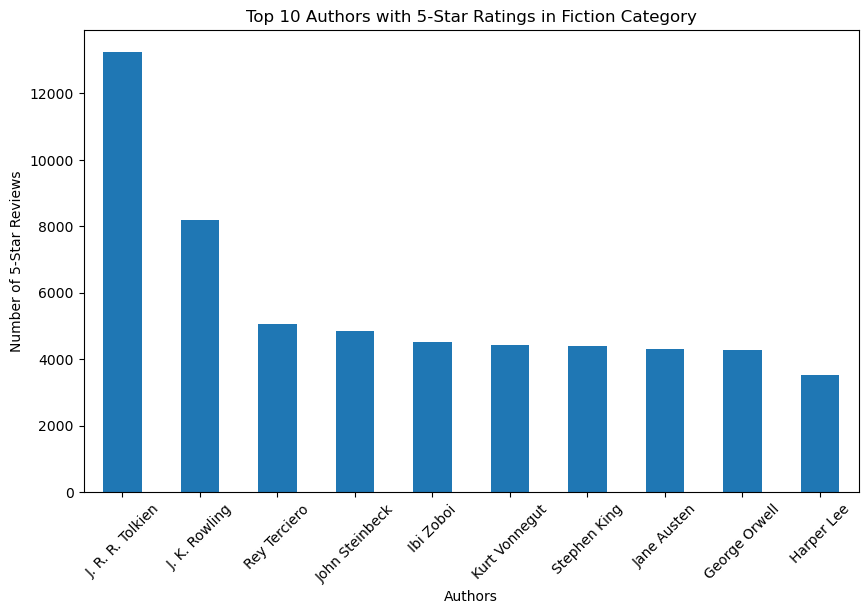

In [ ]:
# Filter the DataFrame to include only the fiction category
fiction_df = df_Processed[df_Processed['categories'].str.contains('Fiction', case=False, na=False)]

# Further filter to include only 5-star ratings
five_star_fiction_df = fiction_df[fiction_df['review/score'] == 5.0]

# Group by the authors and count the number of 5-star reviews for each author
author_five_star_counts = five_star_fiction_df.groupby('authors')['review/text'].count().sort_values(ascending=False)

# Select the top 10 authors with 5-star ratings
top_10_authors = author_five_star_counts.head(10)

# Plot the results
plt.figure(figsize=(10, 6))
top_10_authors.plot(kind='bar')
plt.title('Top 10 Authors with 5-Star Ratings in Fiction Category')
plt.xlabel('Authors')
plt.ylabel('Number of 5-Star Reviews')
plt.xticks(rotation=45)
plt.show()

## The Bottom 10 Authors with 1 Star Ratings in Fiction Category

In [ ]:
# Filter the DataFrame to include only the fiction category
fiction_df = df_Processed[df_Processed['categories'].str.contains('Fiction', case=False, na=False)]

# Further filter to include only 1-star ratings
one_star_fiction_df = fiction_df[fiction_df['review/score'] == 1.0]

# Group by the authors and count the number of 1-star reviews for each author
author_one_star_counts = one_star_fiction_df.groupby('authors')['review/text'].count().sort_values(ascending=True)

# Select the bottom 10 authors with 1-star ratings
bottom_10_authors = author_one_star_counts.head(10)

bottom_10_authors

authors
James Barnes       1
Jill Gregory       1
Jill Jones         1
Jill McCorkle      1
Jill Rubalcaba     1
Jillian Cantor     1
Jillian Hart       1
Shaun Whiteside    1
Jillian Powell     1
Sharyn McCrumb     1
Name: review/text, dtype: int64

## The Number of Fiction Books Published by Year

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-10-ce54a0397b95>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fiction_df['year'] = pd.to_datetime(fiction_df['publishedDate'], errors='coerce').dt.year


1931.0
2022.0


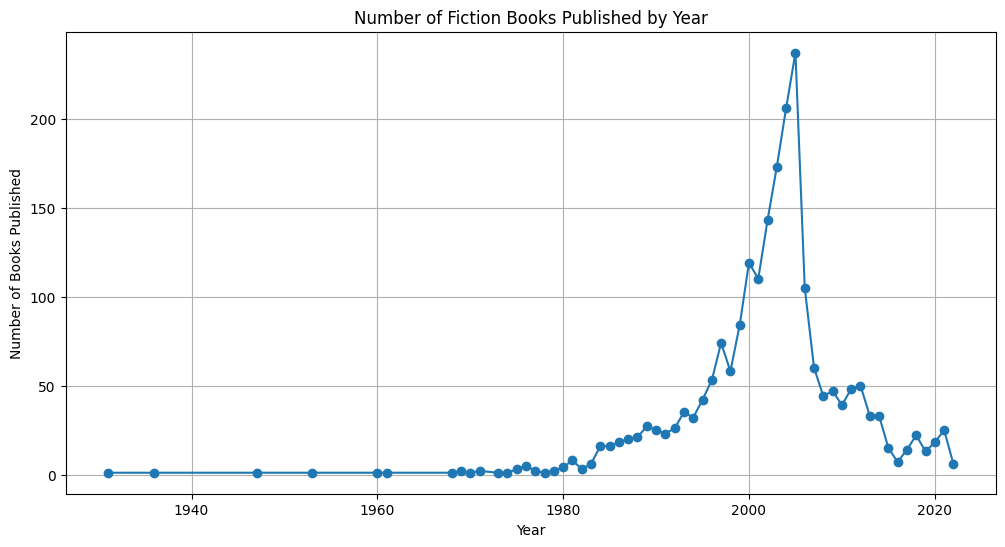

In [10]:
# Filter the DataFrame to include only the fiction category
#fiction_df = df_Processed[df_Processed['categories'].str.contains('Fiction', case=False, na=False)]
fiction_df = df_Data[df_Data['categories'].str.contains('Fiction', case=False, na=False)]

# Extract the year from the publishedDate column
fiction_df['year'] = pd.to_datetime(fiction_df['publishedDate'], errors='coerce').dt.year

# Group by the year and count the number of books published each year
books_published_by_year = fiction_df.groupby('year')['Title'].count()

#Fiction books range
print(str(fiction_df['year'].min()))
print(str(fiction_df['year'].max()))


# Plot the results
plt.figure(figsize=(12, 6))
books_published_by_year.plot(kind='line', marker='o')
plt.title('Number of Fiction Books Published by Year')
plt.xlabel('Year')
plt.ylabel('Number of Books Published')
plt.grid(True)
plt.show()

# Text Mining

## Goal 1 - The features of top 10 most reviewed books in the fiction category.

### Select the Scope of Data to Create Corpus

Criteria:<p>
1. Identify the top 10 most reviewed books in the fiction category.
2.	Filter reviews that have more than 100 words.
3.	Filter books that were published from the year 1900 onwards.

In [ ]:
# Filter the DataFrame to include only the fiction category
fiction_df = df_Processed[df_Processed['categories'].str.contains('Fiction', case=False, na=False)]

# Step 1: Identify the top 5 authors with 5-star ratings in the fiction category
#five_star_fiction_df = fiction_df[fiction_df['review/score'] == 5.0]
#top_5_authors = five_star_fiction_df['authors'].value_counts().head(5).index

# Step 2: Identify the top 5 most reviewed books in the fiction category
book_review_counts = fiction_df.groupby('Title')['review/text'].count().sort_values(ascending=False)
top_10_books = book_review_counts.head(10).index

# Step 3: Filter reviews that have more than 100 words
fiction_df['review_word_count'] = fiction_df['review/text'].apply(lambda x: len(str(x).split()))
reviews_with_min_words = fiction_df[fiction_df['review_word_count'] > 100]

# Step 4: Filter books that were published from the year 2000 onwards
fiction_df['publishedDate'] = pd.to_datetime(fiction_df['publishedDate'], errors='coerce')
recent_books = fiction_df[fiction_df['publishedDate'].dt.year >= 1900]

# Step 5: Combine the criteria
df_corpus1 = recent_books[
    (recent_books['Title'].isin(top_10_books))
]

# Apply the review word count filter again to the final corpus
df_corpus1 = df_corpus1[df_corpus1['review_word_count'] > 100]

# Display the final corpus
df_corpus1.info()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-25-578a237c236c>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fiction_df['review_word_count'] = fiction_df['review/text'].apply(lambda x: len(str(x).split()))
<ipython-input-25-578a237c236c>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

<class 'pandas.core.frame.DataFrame'>
Index: 15753 entries, 78291 to 1736930
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Title              15753 non-null  object        
 1   authors            15753 non-null  object        
 2   publishedDate      15753 non-null  datetime64[ns]
 3   categories         15753 non-null  object        
 4   review/score       15753 non-null  float64       
 5   review/summary     15753 non-null  object        
 6   review/text        15753 non-null  object        
 7   review_word_count  15753 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 1.1+ MB


In [ ]:
df_corpus1['publishedDate'] = df_corpus1['publishedDate'].astype(str).str[:4].astype(int)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
df_corpus1.head(10)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Title,authors,publishedDate,categories,review/score,review/summary,review/text,review_word_count
78291,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,5.0,Teachers buy this over iTunes or Audible versi...,I bought the audio CD's about 5 years ago from...,261
78298,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,5.0,"A map, the book, and GOLD PAGES :O","Any fan, or non fan will love this. First of a...",124
78307,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,5.0,A classic that only gets better with age,A true good versus evil story and what is best...,129
78309,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,3.0,The Hobbit in Review,The Hobbit is a book about and hobbit named Bi...,146
78310,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,3.0,My Hobbit Review,This is a story about a Hobbit whose name is B...,443
78314,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,1.0,Wont' work on Kindle FIRE,I admit I didn't read the fine print on this a...,114
78318,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,3.0,"Interesting little tale, but definitely more f...",Although an oft amusing little tale (I especia...,168
78339,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,4.0,Bilbo's Journey,Bilbo Baggins the hobbit was just about to hav...,181
78340,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,4.0,Bilbo's Journey,Bilbo Baggins the hobbit was just about to hav...,179
78344,"The Hobbitt, or there and back again; illustra...",J. R. R. Tolkien,2013,Fiction,5.0,Hobbit--An Old Freind and a Great Book,"I loved this book. When I was four, five, and ...",214


### Export the Selected Data

In [ ]:
df_corpus1.to_csv('corpus1.csv', index=False)
df_corpus1.shape

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


(15753, 8)

In [ ]:
df_corpus1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15753 entries, 78291 to 1736930
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              15753 non-null  object 
 1   authors            15753 non-null  object 
 2   publishedDate      15753 non-null  int64  
 3   categories         15753 non-null  object 
 4   review/score       15753 non-null  float64
 5   review/summary     15753 non-null  object 
 6   review/text        15753 non-null  object 
 7   review_word_count  15753 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 1.1+ MB


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
authors_publishedDate = df_corpus1.groupby('authors')['Title'].value_counts().fillna(0)
authors_publishedDate

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


authors           Title                                                           
J. K. Rowling     Harry Potter and The Sorcerer's Stone                               2534
                  Harry Potter and the Chamber of Secrets                             1031
J. R. R. Tolkien  The Hobbit                                                          1275
                  The Hobbit or There and Back Again                                  1268
                  The Hobbitt, or there and back again; illustrated by the author.    1266
J.D. Salinger     THE CATCHER IN THE RYE                                              1792
John Donovan      The Catcher in the Rye [Audiobook] [Cd] [Unabridged] (Audio CD)     1793
Lois Lowry        The Giver                                                           1903
Louis Sachar      Holes                                                               1518
Thomas Harris     Hannibal                                                            1373
Name: c

In the text mining preprocessing, the NLTK packages were used to perform:<p>
1. Tokenization
2. Token Normalization
3. Stopping Words
4. Stemming & Lemmatization

### Tokenization & Token Normalization<p>
1. Remove Punctuation
2. Remove Numbers
3. Remove Separators
4. Remove Symbols
5. To Lower Case<br>
By using isalpha() and lower() functions.

In [ ]:
def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Convert to lower case and remove non-alphabetic characters
    words = [token.lower() for token in tokens if token.isalpha()]
    return words

df_corpus1['review/text_tokenized'] = df_corpus1['review/text'].apply(preprocess_text)
print(df_corpus1[['review/text', 'review/text_tokenized']].head(5))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


                                             review/text  \
78291  I bought the audio CD's about 5 years ago from...   
78298  Any fan, or non fan will love this. First of a...   
78307  A true good versus evil story and what is best...   
78309  The Hobbit is a book about and hobbit named Bi...   
78310  This is a story about a Hobbit whose name is B...   

                                   review/text_tokenized  
78291  [i, bought, the, audio, cd, about, years, ago,...  
78298  [any, fan, or, non, fan, will, love, this, fir...  
78307  [a, true, good, versus, evil, story, and, what...  
78309  [the, hobbit, is, a, book, about, and, hobbit,...  
78310  [this, is, a, story, about, a, hobbit, whose, ...  


### Remove Stopping Words

In [ ]:
stop_words = set(stopwords.words('english'))


# Add book titles to the stop words list
book_titles = df_corpus1['Title'].unique()  # Assuming the column 'Title' contains book titles
additional_stops = [' '.join(word_tokenize(title.lower())) for title in book_titles]  # Tokenize and normalize titles
common_words = ['book', 'books', 'read', 'reading', 'story', 'stories', 'author', 'authors', 'novel', 'novels', 'men', 'women', 'man', 'woman', 'people', 'what', 'where', 'when', 'why', 'how', 'whose', 'quot']
stop_words.update(additional_stops)
stop_words.update(common_words)

# Now apply the filtering with the updated stop words
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

df_corpus1['review/text_nostop'] = df_corpus1['review/text_tokenized'].apply(remove_stopwords)
print(df_corpus1[['review/text', 'review/text_tokenized', 'review/text_nostop']].head(5))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


                                             review/text  \
78291  I bought the audio CD's about 5 years ago from...   
78298  Any fan, or non fan will love this. First of a...   
78307  A true good versus evil story and what is best...   
78309  The Hobbit is a book about and hobbit named Bi...   
78310  This is a story about a Hobbit whose name is B...   

                                   review/text_tokenized  \
78291  [i, bought, the, audio, cd, about, years, ago,...   
78298  [any, fan, or, non, fan, will, love, this, fir...   
78307  [a, true, good, versus, evil, story, and, what...   
78309  [the, hobbit, is, a, book, about, and, hobbit,...   
78310  [this, is, a, story, about, a, hobbit, whose, ...   

                                      review/text_nostop  
78291  [bought, audio, cd, years, ago, used, store, w...  
78298  [fan, non, fan, love, first, great, like, size...  
78307  [true, good, versus, evil, best, hero, always,...  
78309  [hobbit, hobbit, named, bilbo, dwar

### Stemming & Lemmatisation

In [ ]:
# Initialize the stemmer and the lemmatizer.
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
def get_wordnet_pos(word):
    """Map NLTK part of speech tags to WordNet part of speech tags."""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

    return tag_dict.get(tag, wordnet.NOUN)  # Default to NOUN

def stem_and_lemmatize(words):
    stemmed = [stemmer.stem(word) for word in words]
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in words]
    return stemmed, lemmatized

df_corpus1[['review/text_stemmed', 'review/text_lemmatized']] = df_corpus1['review/text_nostop'].apply(
    lambda words: pd.Series(stem_and_lemmatize(words)))

print(df_corpus1[['review/text', 'review/text_stemmed', 'review/text_lemmatized']].head())

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


                                             review/text  \
78291  I bought the audio CD's about 5 years ago from...   
78298  Any fan, or non fan will love this. First of a...   
78307  A true good versus evil story and what is best...   
78309  The Hobbit is a book about and hobbit named Bi...   
78310  This is a story about a Hobbit whose name is B...   

                                     review/text_stemmed  \
78291  [bought, audio, cd, year, ago, use, store, wel...   
78298  [fan, non, fan, love, first, great, like, size...   
78307  [true, good, versu, evil, best, hero, alway, t...   
78309  [hobbit, hobbit, name, bilbo, dwarv, dwarv, ta...   
78310  [hobbit, name, bilbo, baggin, one, morn, thirt...   

                                  review/text_lemmatized  
78291  [bought, audio, cd, year, ago, use, store, wel...  
78298  [fan, non, fan, love, first, great, like, size...  
78307  [true, good, versus, evil, best, hero, always,...  
78309  [hobbit, hobbit, name, bilbo, dwarf

### Keywords Extraction

### TF-IDF

In [ ]:
# Assuming 'lemmatized_review' is the column after preprocessing and lemmatization
df_corpus1['review/text_tfidf'] = df_corpus1['review/text_lemmatized'].apply(lambda x: ' '.join(x))

# Consider both unigrams and bigrams.
tfidf_vectorizer = TfidfVectorizer(max_df=0.98, min_df=2, max_features=2000, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(df_corpus1['review/text_tfidf'])

# Get feature names to use as DataFrame column headers
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_feature_names)
print(tfidf_df.head(10))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


   ability  able  absolute  absolutely  accept  accepted  accompany  account  \
0      0.0   0.0       0.0         0.0     0.0       0.0   0.000000      0.0   
1      0.0   0.0       0.0         0.0     0.0       0.0   0.000000      0.0   
2      0.0   0.0       0.0         0.0     0.0       0.0   0.000000      0.0   
3      0.0   0.0       0.0         0.0     0.0       0.0   0.000000      0.0   
4      0.0   0.0       0.0         0.0     0.0       0.0   0.000000      0.0   
5      0.0   0.0       0.0         0.0     0.0       0.0   0.000000      0.0   
6      0.0   0.0       0.0         0.0     0.0       0.0   0.000000      0.0   
7      0.0   0.0       0.0         0.0     0.0       0.0   0.141503      0.0   
8      0.0   0.0       0.0         0.0     0.0       0.0   0.142224      0.0   
9      0.0   0.0       0.0         0.0     0.0       0.0   0.000000      0.0   

   accuse  accuse steal  ...  young  young adult  young boy  young child  \
0     0.0           0.0  ...    0.0        

1. max_df

	Purpose: Used to remove terms that appear too frequently, also known as “corpus-specific stop words”. <br>
	Type: Float in range [0.0, 1.0] or int. <br>
	Behavior: <br>
	•	If float, the parameter represents a proportion of documents. <br>
	•	If int, it represents an absolute count. <br>
	Example: max_df=0.95 means “ignore terms that appear in more than 95% of the documents”. This is because such terms are less likely to carry meaningful information specific to documents since they are too common. <p>

2. min_df

	Purpose: Used to remove terms that appear too infrequently. <br>
	Type: Float in range [0.0, 1.0] or int.<br>
	Behavior:<br>
	•	If float, the parameter represents a proportion of documents.<br>
	•	If int, it represents an absolute count.<br>
	Example: min_df=2 means “ignore terms that appear in fewer than 2 documents”. This helps to focus on words that have at least some significance across the corpus rather than being potentially random noise.<p>

3. max_features

	Purpose: Used to limit the amount of features (i.e., terms) that the vectorizer includes in the term-document matrix. <br>
	Type: Int. <br>
	Behavior: The vectorizer will choose the terms with the highest TF-IDF scores across the corpus up to the specified number.<br>
	Example: max_features=1000 means “limit the number of features to the top 1000 by term frequency across the document set”. This is useful for reducing dimensionality and improving efficiency, particularly when dealing with very large text data sets.

Extract top keywords for each document by selecting the words with the highest TF-IDF scores.

In [ ]:
def top_tfidf_feats(row, features, top_n=30):
    """Get top n tfidf values in row and return them with their corresponding feature names."""
    topn_ids = row.argsort()[-top_n:][::-1]  # Indices sorted by value
    top_feats = [(features[i], row[i]) for i in topn_ids]
    df = pd.DataFrame(top_feats, columns=['feature', 'tfidf'])
    return df

# Apply this function to each row in the tfidf DataFrame
top_tfidf = tfidf_df.apply(lambda x: top_tfidf_feats(x, tfidf_feature_names), axis=1)
print(top_tfidf.iloc[0])  # Print top tf-idf features for the first document

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


      feature     tfidf
0          cd  0.586723
1       audio  0.272026
2      minute  0.257735
3      player  0.254577
4        long  0.210812
5        play  0.204908
6        hour  0.147887
7       voice  0.147102
8      bought  0.146845
9       start  0.132529
10       stop  0.126103
11        use  0.104622
12     faster  0.098351
13   multiple  0.095222
14       jump  0.094298
15    section  0.093529
16      store  0.090318
17  paragraph  0.090054
18      match  0.089288
19     refuse  0.089205
20  somewhere  0.088635
21        key  0.087477
22      brave  0.085311
23       luck  0.082542
24     choose  0.081730
25   narrator  0.081677
26       fine  0.079601
27       slow  0.078565
28      issue  0.076208
29       half  0.073844


Visualize the top TF-IDF features in the corpus.

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


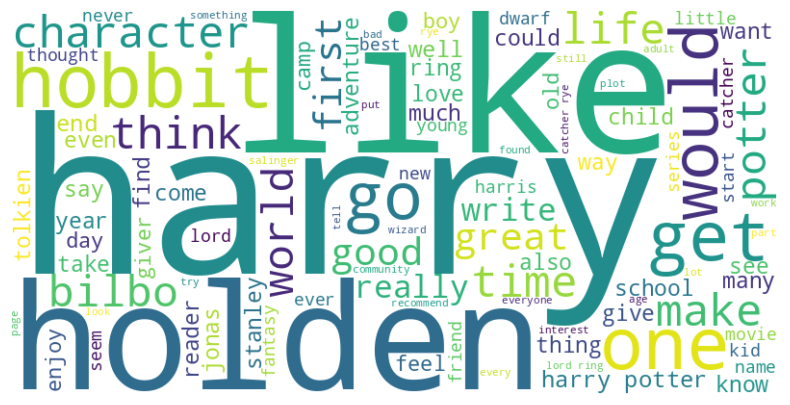

In [ ]:
top_words = tfidf_df.sum(axis=0).sort_values(ascending=False)[:100]

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white')

# Generate a word cloud using TF-IDF scores
wordcloud.generate_from_frequencies(top_words.to_dict())

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Don't show axes to keep it clean
plt.show()

### Topic Modeling (LDA)

Convert the preprocessed documents into a format that Gensim can use!

In [ ]:
# Create a dictionary representation of the documents
dictionary = corpora.Dictionary(df_corpus1['review/text_lemmatized'])

# Filter out extremes to remove infrequent and too frequent words
dictionary.filter_extremes(no_below=15, no_above=0.5, keep_n=100000)

# Convert document into the bag-of-words (BoW) format = list of (token_id, token_count) tuples
corpus = [dictionary.doc2bow(doc) for doc in df_corpus1['review/text_lemmatized']]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=1):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        model = LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

# Assuming you have 'dictionary', 'corpus', and 'texts' prepared from your dataset
model_list, coherence_values = compute_coherence_values(dictionary=dictionary, corpus=corpus, texts=df_corpus1['review/text_lemmatized'], limit=20)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


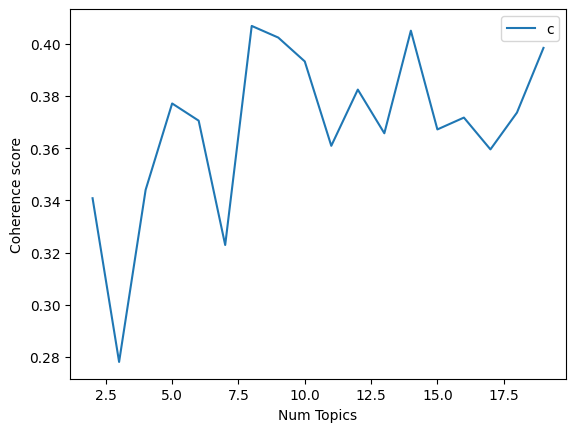

In [ ]:
limit=20
start=2
step=1
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [ ]:
# Find the number of topics with the highest coherence score
optimal_index = coherence_values.index(max(coherence_values))
optimal_num_topics = x[optimal_index]
print(f"Optimal number of topics: {optimal_num_topics}")

Optimal number of topics: 8


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Build the LDA Model

In [ ]:
# Set training parameters
num_topics = 8 # Number of topics to extract
passes = 15 # Number of passes through the corpus during training
iterations = 100 # Maximum number of iterations through the corpus when inferring the topic distribution of a corpus
eval_every = None  # Don't evaluate model perplexity, takes too much time

# Create an LDA model using the corpus
lda_model = LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary,
                     passes=passes, iterations=iterations, eval_every=eval_every)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Visualize the topics
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


View the Topics

In [ ]:
# Print the Keyword in the 5 topics
topics = lda_model.print_topics(num_words=5)
for topic in topics:
    print(topic)

(0, '0.037*"jonas" + 0.029*"giver" + 0.025*"memory" + 0.022*"community" + 0.021*"world"')
(1, '0.042*"holden" + 0.014*"life" + 0.011*"salinger" + 0.011*"school" + 0.009*"caulfield"')
(2, '0.052*"hobbit" + 0.035*"bilbo" + 0.026*"tolkien" + 0.025*"ring" + 0.020*"dwarf"')
(3, '0.074*"stanley" + 0.056*"camp" + 0.037*"lake" + 0.032*"green" + 0.027*"boy"')
(4, '0.083*"harry" + 0.042*"catcher" + 0.041*"potter" + 0.038*"rye" + 0.017*"school"')
(5, '0.026*"get" + 0.020*"go" + 0.019*"think" + 0.019*"would" + 0.019*"really"')
(6, '0.019*"character" + 0.018*"harris" + 0.014*"reader" + 0.013*"lecter" + 0.012*"end"')
(7, '0.015*"first" + 0.014*"time" + 0.013*"child" + 0.012*"year" + 0.010*"well"')


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


According to the coherence score metric, 5 topics provide the most meaningful and interpretable set of topics for this particular dataset.

## Goal 2 - The trend of fiction book in recent 10 years

### Select the Scope of Data to Create Corpus

Criteria:<p>
1. Recent 10 years
2. The review/score should be at least 4
3. The word count should be at least 100
4. In fiction category

In [11]:
# Filter the DataFrame to include only the fiction category
fiction_df = df_Processed[df_Processed['categories'].str.contains('Fiction', case=False, na=False)]

#goodratings_fiction_df = fiction_df[fiction_df['review/score'] >= 4.0]
#top_5_authors = five_star_fiction_df['authors'].value_counts().head(5).index

fiction_df['review_word_count'] = fiction_df['review/text'].apply(lambda x: len(str(x).split()))

fiction_df['publishedDate'] = pd.to_datetime(fiction_df['publishedDate'], errors='coerce')
recent_books = fiction_df[fiction_df['publishedDate'].dt.year >= 2013]

# Step 5: Combine the criteria
df_corpus2 = recent_books[
    (recent_books['review/score'] >= 4.0)
]

# Apply the review word count filter again to the final corpus
df_corpus2 = df_corpus2[df_corpus2['review_word_count'] > 100]

# Display the final corpus
df_corpus2.info()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-11-b9846aa3d91e>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fiction_df['review_word_count'] = fiction_df['review/text'].apply(lambda x: len(str(x).split()))
<ipython-input-11-b9846aa3d91e>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

<class 'pandas.core.frame.DataFrame'>
Index: 86598 entries, 278 to 2091633
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Title              86598 non-null  object        
 1   authors            86598 non-null  object        
 2   publishedDate      86598 non-null  datetime64[ns]
 3   categories         86598 non-null  object        
 4   review/score       86598 non-null  float64       
 5   review/summary     86598 non-null  object        
 6   review/text        86598 non-null  object        
 7   review_word_count  86598 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 5.9+ MB


In [12]:
df_corpus2['publishedDate'] = df_corpus2['publishedDate'].astype(str).str[:4].astype(int)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [13]:
df_corpus2.head(10)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Title,authors,publishedDate,categories,review/score,review/summary,review/text,review_word_count
278,Seance,Kevin Valgaeren,2016,Fiction,5.0,Tales of the world I never knew and never will,"Thanks to my grandparents, who came to America...",324
279,Seance,Kevin Valgaeren,2016,Fiction,5.0,Excellent - as good as it gets!,Isaac Bashevis Singer was no doubt one of the ...,136
281,Seance,Kevin Valgaeren,2016,Fiction,4.0,Short stories that use Jewish peasant life to ...,THE S&Eacute;ANCE AND OTHER STORIES is a colle...,227
364,Night World: Daughters Of Darkness,L.J. Smith,2016,Juvenile Fiction,5.0,one of the best night world books!!!!,first of all i thought that this was one of lj...,211
374,Night World: Daughters Of Darkness,L.J. Smith,2016,Juvenile Fiction,5.0,The Best of the Night World,Though the plot is much like that of Pride and...,210
377,Night World: Daughters Of Darkness,L.J. Smith,2016,Juvenile Fiction,5.0,This book is one of my favorates.,I have read just about everything L.J. Smith h...,170
379,Night World: Daughters Of Darkness,L.J. Smith,2016,Juvenile Fiction,5.0,Second Book in the Night World Series,"Set in Briar Creek, Oregon, ""Daughters of Dark...",233
380,Night World: Daughters Of Darkness,L.J. Smith,2016,Juvenile Fiction,5.0,This book had me giggling,"I'm sorry, but I just find the way Mary Lennet...",205
381,Night World: Daughters Of Darkness,L.J. Smith,2016,Juvenile Fiction,5.0,Another awesome book from LJ Smith!,"Daughters of Darkness, the second book in LJ S...",186
382,Night World: Daughters Of Darkness,L.J. Smith,2016,Juvenile Fiction,5.0,THIS IS MY FAV BOOK IN THE SERIES!!!!,This is the best book out of the Night World s...,236


### Export the Selected Data

In [ ]:
df_corpus2.to_csv('corpus2.csv', index=False)
df_corpus2.shape

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


(86598, 8)

In [ ]:
df_corpus2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86598 entries, 278 to 2091633
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              86598 non-null  object 
 1   authors            86598 non-null  object 
 2   publishedDate      86598 non-null  int64  
 3   categories         86598 non-null  object 
 4   review/score       86598 non-null  float64
 5   review/summary     86598 non-null  object 
 6   review/text        86598 non-null  object 
 7   review_word_count  86598 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 5.9+ MB


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### Tokenization & Token Normalization

In [14]:
def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Convert to lower case and remove non-alphabetic characters
    words = [token.lower() for token in tokens if token.isalpha()]
    return words

df_corpus2['review/text_tokenized'] = df_corpus2['review/text'].apply(preprocess_text)
print(df_corpus2[['review/text', 'review/text_tokenized']].head(5))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


                                           review/text  \
278  Thanks to my grandparents, who came to America...   
279  Isaac Bashevis Singer was no doubt one of the ...   
281  THE S&Eacute;ANCE AND OTHER STORIES is a colle...   
364  first of all i thought that this was one of lj...   
374  Though the plot is much like that of Pride and...   

                                 review/text_tokenized  
278  [thanks, to, my, grandparents, who, came, to, ...  
279  [isaac, bashevis, singer, was, no, doubt, one,...  
281  [the, s, eacute, ance, and, other, stories, is...  
364  [first, of, all, i, thought, that, this, was, ...  
374  [though, the, plot, is, much, like, that, of, ...  


### Removing Stopping Words

In [15]:
stop_words = set(stopwords.words('english'))


# Add book titles to the stop words list
book_titles = df_corpus1['Title'].unique()  # Assuming the column 'Title' contains book titles
additional_stops = [' '.join(word_tokenize(title.lower())) for title in book_titles]  # Tokenize and normalize titles
common_words = ['book', 'books', 'read', 'reading', 'story', 'stories', 'author', 'authors', 'novel', 'novels', 'men', 'women', 'man', 'woman', 'people', 'what', 'where', 'when', 'why', 'how', 'whose', 'quot']
stop_words.update(additional_stops)
stop_words.update(common_words)

# Now apply the filtering with the updated stop words
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

df_corpus2['review/text_nostop'] = df_corpus2['review/text_tokenized'].apply(remove_stopwords)
print(df_corpus2[['review/text', 'review/text_tokenized', 'review/text_nostop']].head(5))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


                                           review/text  \
278  Thanks to my grandparents, who came to America...   
279  Isaac Bashevis Singer was no doubt one of the ...   
281  THE S&Eacute;ANCE AND OTHER STORIES is a colle...   
364  first of all i thought that this was one of lj...   
374  Though the plot is much like that of Pride and...   

                                 review/text_tokenized  \
278  [thanks, to, my, grandparents, who, came, to, ...   
279  [isaac, bashevis, singer, was, no, doubt, one,...   
281  [the, s, eacute, ance, and, other, stories, is...   
364  [first, of, all, i, thought, that, this, was, ...   
374  [though, the, plot, is, much, like, that, of, ...   

                                    review/text_nostop  
278  [thanks, grandparents, came, america, first, d...  
279  [isaac, bashevis, singer, doubt, one, greatest...  
281  [eacute, ance, collection, isaac, bashevis, si...  
364  [first, thought, one, lj, smith, best, written...  
374  [though, plo

### Stemming & Lemmatisation

In [16]:
# Initialize the stemmer and the lemmatizer.
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [17]:
def get_wordnet_pos(word):
    """Map NLTK part of speech tags to WordNet part of speech tags."""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

    return tag_dict.get(tag, wordnet.NOUN)  # Default to NOUN

def stem_and_lemmatize(words):
    stemmed = [stemmer.stem(word) for word in words]
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in words]
    return stemmed, lemmatized

df_corpus2[['review/text_stemmed', 'review/text_lemmatized']] = df_corpus2['review/text_nostop'].apply(
    lambda words: pd.Series(stem_and_lemmatize(words)))

print(df_corpus2[['review/text', 'review/text_stemmed', 'review/text_lemmatized']].head())

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


                                           review/text  \
278  Thanks to my grandparents, who came to America...   
279  Isaac Bashevis Singer was no doubt one of the ...   
281  THE S&Eacute;ANCE AND OTHER STORIES is a colle...   
364  first of all i thought that this was one of lj...   
374  Though the plot is much like that of Pride and...   

                                   review/text_stemmed  \
278  [thank, grandpar, came, america, first, decad,...   
279  [isaac, bashevi, singer, doubt, one, greatest,...   
281  [eacut, anc, collect, isaac, bashevi, singer, ...   
364  [first, thought, one, lj, smith, best, written...   
374  [though, plot, much, like, pride, prejudic, re...   

                                review/text_lemmatized  
278  [thanks, grandparent, come, america, first, de...  
279  [isaac, bashevis, singer, doubt, one, great, s...  
281  [eacute, ance, collection, isaac, bashevis, si...  
364  [first, thought, one, lj, smith, best, write, ...  
374  [though, plo

In [ ]:
df_corpus2.info()

### Coherence Score Metric

In [18]:
texts = df_corpus2['review/text_lemmatized'].tolist()  # List of lemmatized reviews
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [19]:
limit = 15  # Maximum number of topics
start = 3   # Minimum number of topics
step = 1

model_list = []
coherence_values = []

for num_topics in range(start, limit, step):
    model = LdaModel(corpus=corpus, num_topics=num_topics, id2word=dictionary, passes=10, random_state=100)
    model_list.append(model)
    coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


KeyboardInterrupt: 

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


ValueError: x and y must have same first dimension, but have shapes (12,) and (7,)

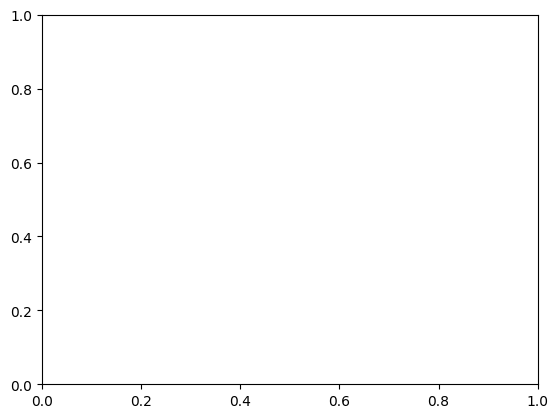

In [20]:
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.title("Coherence Scores for Different Numbers of Topics")
plt.show()

In [ ]:
# Find the number of topics with the highest coherence score
optimal_index = coherence_values.index(max(coherence_values))
optimal_num_topics = x[optimal_index]
print(f"Optimal number of topics: {optimal_num_topics}")

In [ ]:
optimal_model = model_list[optimal_index]
optimal_model.print_topics(num_words=10)

### Topic Modeling

In [21]:
# Build the LDA model
lda_model = LdaModel(corpus, num_topics=12, id2word=dictionary, passes=10, random_state=100)

# Print the topics found by the LDA model
topics = lda_model.print_topics(num_words=5)
for topic in topics:
    print(topic)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


(0, '0.012*"life" + 0.009*"human" + 0.009*"world" + 0.009*"one" + 0.007*"many"')
(1, '0.047*"whale" + 0.035*"melville" + 0.033*"dick" + 0.031*"moby" + 0.026*"ahab"')
(2, '0.043*"de" + 0.024*"hemingway" + 0.021*"la" + 0.017*"poem" + 0.016*"translation"')
(3, '0.025*"like" + 0.021*"get" + 0.018*"one" + 0.017*"would" + 0.017*"go"')
(4, '0.041*"jane" + 0.023*"love" + 0.020*"character" + 0.016*"elizabeth" + 0.015*"marriage"')
(5, '0.036*"character" + 0.013*"reader" + 0.011*"one" + 0.010*"plot" + 0.009*"end"')
(6, '0.022*"life" + 0.021*"love" + 0.017*"family" + 0.013*"girl" + 0.011*"father"')
(7, '0.012*"war" + 0.008*"heinlein" + 0.007*"world" + 0.006*"one" + 0.006*"take"')
(8, '0.039*"child" + 0.022*"boy" + 0.015*"anne" + 0.015*"kid" + 0.011*"adult"')
(9, '0.015*"one" + 0.011*"write" + 0.011*"time" + 0.010*"first" + 0.009*"well"')
(10, '0.064*"god" + 0.042*"faith" + 0.033*"christian" + 0.015*"christianity" + 0.015*"christ"')
(11, '0.021*"mystery" + 0.015*"murder" + 0.012*"series" + 0.009*"f

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


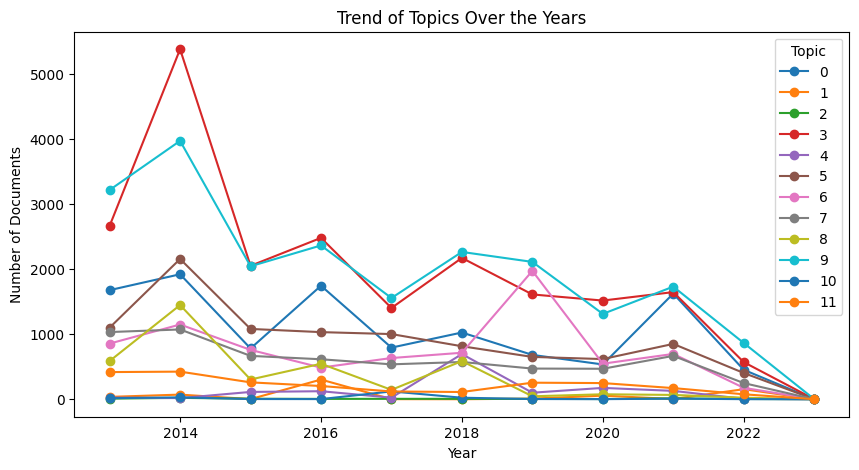

In [22]:
# Assign topics to each document
topic_distribution = [max(lda_model[doc], key=lambda x: x[1])[0] for doc in corpus]

# Add topic distribution to DataFrame
df_corpus2['dominant_topic'] = topic_distribution

# Group by year and dominant topic to see the trend
trend_over_years = df_corpus2.groupby(['publishedDate', 'dominant_topic']).size().unstack().fillna(0)

# Plotting
trend_over_years.plot(kind='line', figsize=(10, 5), marker='o')
plt.title('Trend of Topics Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Documents')
plt.legend(title='Topic')
plt.show()

In [23]:
# Visualize the topics
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
